# Dimer Case IV:  QME

In [1]:
%run dimer-case4-functions.ipynb

## Zeroth-order approximation

In [2]:
# Parameters
gamma0 = 1
a = 0.01  # dimensionless distance a = r/lambda0
r12 = a*2*np.pi #  r12= k0*(a*lambda0)
theta_dipole = np.pi/2
chi = np.pi/2

gamma_phi = 1e6*gamma0
P = 10
gamma0=1

H=hamiltonian()
Omega = ddcoupling(r12,theta_dipole)
gamma = decay_rate(r12,theta_dipole)

v, label_p = pbasis()
u, label_d = dicke(v)

c_ops = collapse_ops(P,gamma,gamma_phi,u)

# detector operators
sz, sp, sm = spin_ops()
theta_detect = np.pi/2
phi_detect = 0
nhat = detector_pos(theta_detect,phi_detect)
r=emitter_pos(r12)
D1=np.exp(-1j*np.inner(nhat,r[0])) * sm[0]
D2=np.exp(-1j*np.inner(nhat,r[1])) * sm[1]
D = [D1,D2]
DD = D1+D2


In [3]:
rho_ss_qme = steadystate(H,c_ops)

In [4]:
M = rate_matrix(P,gamma0)
pop0 = np.array([1,0,0,0])
times = np.linspace(0,100,100)
result = popsolve(M,pop0,times,e_ops=[sz[0],sz[1]])
p_ss_pop = result.populations[-1]
rho_ss_pop = result.states[-1]
p_ss_th, rho_ss_th = steadypops(P,gamma0)

**Checking the steady state population**

In [5]:
print("state     qme       pop      theory")
for k in range(4):
    print("  {0:3s}   {1:6.4f}    {2:6.4f}     {3:6.4f}"
        .format(label_p[k],rho_ss_qme[k,k].real,p_ss_pop[k],p_ss_th[k]))

state     qme       pop      theory
  ee    0.8264    0.8264     0.8264
  eg    0.0826    0.0826     0.0826
  ge    0.0826    0.0826     0.0826
  gg    0.0083    0.0083     0.0083


### Second-order coherence function

We calculate $g^{(2)}(\tau)$ using the two detector models as before.

**Detector model I**

The result is similar to other cases and we found $g^{(2)}(0) = 0.5$, which consistent with $1-\tfrac{1}{N}$.

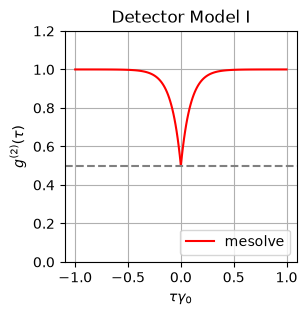

In [6]:
times = np.linspace(0,1,100)

I1 = 0
for k in range(2):
    I1 += expect(D[k].dag()*D[k],rho_ss_pop)

G2 = 0
for i in range(2):
    for j in range(2):
        rho_c = D[i]*rho_ss_pop*D[i].dag()
        p = []
        for k in range(4):
            p.append(rho_c[k,k].real) 
        pop0 = np.array(p)    
        e_ops = D[j].dag()*D[j]
        result = popsolve(M,pop0,times,e_ops=[e_ops])
        G2 += np.array(result.expect[0])      
 
g2_D12 = G2/I1**2
plt.figure(figsize=(3,3))
plt.title("Detector Model I")
plt.plot(times, np.real(g2_D12),c='r',label='mesolve')
plt.plot(-times,np.real(g2_D12),c='r')
plt.xlabel(r'$\tau\gamma_{0}$')
plt.ylabel(r'$g^{(2)}(\tau)$')
plt.axhline(y=0.5,color='grey',ls='--')
plt.ylim([0,1.2])
plt.legend(loc=4)
plt.grid(True)
plt.show()

**Detector model II**

In the absence of pure dephasing, $g^{(2)}(\tau)$ measured by the second model of detector is constant in time and $g^{(2)}(0) = 1$ in agreement with $2 \left(1-\tfrac{1}{N}\right)$.  When pure depahsing is included, the detector model II generates the same $g^{(2)}$ and the model one, except that $g^{(0)}(0)=1$.  The vcertical line at $\tau=0$ in the plot is actually a peak with very narrow width. Since the dephasing cannot affect two photons arriving at the same time, $g^{(0)}(0)=1$ is expected.  However, it falls down to $0.5$ at the dephasing rate.  There is no coherence between two photons separated by time difference longer than $\gamma_{\phi}^{-1}$. The curve gradually rises to $1$ in the same manner as the detector model I shows.   The drop is so quick ($\sim 100 \text{ fs}$) that it may not show up in the measurement with low time resolution.

In [7]:
#-- g2 with popuplation dynamics
e_ops = DD.dag()*DD
rho_c = DD*rho_ss_th*DD.dag()
I2 = rho_c.tr()
p = []
for k in range(4):
    p.append(rho_c[k,k].real)
    
pop0 = np.array(p)
times_long = np.linspace(0,1,100)
result = popsolve(M,pop0,times_long,e_ops=[e_ops])
g2_pop = np.array(result.expect[0])/I2**2

In [8]:
#-- magnifying near tau=0 using full qme
times_short = np.linspace(0,1,100)/gamma_phi
rho_0 = DD*rho_ss_qme*DD.dag()
I2 = rho_c.tr()
e_ops = DD.dag()*DD
result = mesolve(H,rho_0,times_short,c_ops,e_ops=e_ops)      
g2_qme = result.expect[0]/I2**2

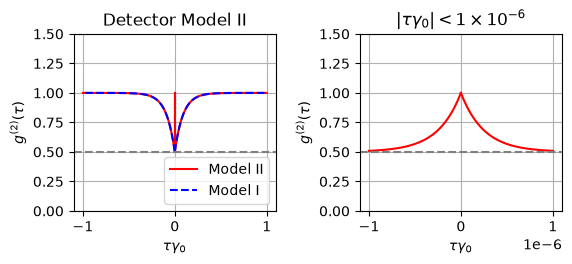

In [9]:

plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plt.title("Detector Model II")
plt.plot(times_long, np.real(g2_pop),c='r',label="Model II")
plt.plot(-times_long,np.real(g2_pop),c='r')
plt.plot(times_short, np.real(g2_qme),c='r')
plt.plot(-times_short,np.real(g2_qme),c='r')
plt.plot(times_long, np.real(g2_D12),c='b',ls='--',label="Model I")
plt.plot(-times_long,np.real(g2_D12),c='b',ls='--')
plt.xlabel(r'$\tau\gamma_{0}$')
plt.ylabel(r'$g^{(2)}(\tau)$')
plt.ylim([0,1.5])
plt.axhline(y=0.5,color='grey',ls='--')
plt.legend(loc=4)
plt.grid(True)

plt.subplot(1,2,2)
plt.title(r"$|\tau\gamma_{0}| < 1\times 10^{-6}$")
plt.plot(times_short, np.real(g2_qme),c='r')
plt.plot(-times_short,np.real(g2_qme),c='r')
plt.xlabel(r'$\tau\gamma_{0}$')
plt.ylabel(r'$g^{(2)}(\tau)$')
plt.ylim([0,1.5])
plt.grid(True)
plt.axhline(y=0.5,color='grey',ls='--')
plt.tight_layout(pad=2.0)
plt.show()
